In [1]:
from PSO import PSOFeatureSelection, StandardScaler
from base_utils import load_test, load_train, numeric_columns, categorical_columns, selected_features, categorical
from transforemr import FTTransformer, train_model

import numpy as np
import pandas as pd

from sklearn.preprocessing import  OrdinalEncoder
from imblearn.under_sampling import RandomUnderSampler

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, random_split



In [2]:
# # Define the input data based on the model parameters
# categorical_data = torch.tensor([[0, 1, 2],  # Example input for categorical features
#                                  [0, 0, 1],
#                                  [1, 1, 2]])  # 3 examples, 3 categorical features

# numerical_data = torch.tensor([[0.5],  # Example input for numerical features
#                                [1.2],
#                                [0.9]])  # 3 examples, 1 numerical feature

# args = {
#     "embed_size" : 128, 
#     "heads" : 8,
#     "depth" : 1, 
#     "num_classes" : 1,
#     "num_categorical" : [10, 12, 3], 
#     "num_numerical" : 1, 
#     "embedding_dim" : 16, 
#     "dropout" : 0.1
# }

# model = FTTransformer(**args)

# # Pass the data through the model
# output = model(categorical_data, numerical_data)

# print(output)

In [3]:
train_df = load_train()
test_df = load_test()

train_df[numeric_columns] = train_df[numeric_columns].fillna(0)
test_df[numeric_columns] = test_df[numeric_columns].fillna(0)

Y = train_df["임신 성공 여부"]
X = train_df.drop(["임신 성공 여부"], axis=1)

undersampler = RandomUnderSampler(random_state=42)
X, Y = undersampler.fit_resample(X, Y)

for col in categorical_columns:
    X[col] = X[col].astype(str)
    test_df[col] = test_df[col].astype(str)

ordinal_encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)

X_train_encoded = X.copy()
X_train_encoded[categorical_columns] = ordinal_encoder.fit_transform(X[categorical_columns])
# X_train_encoded = X_train_encoded[d]

X_test_encoded = test_df.copy()
X_test_encoded[categorical_columns] = ordinal_encoder.transform(test_df[categorical_columns])
# X_test_encoded = X_test_encoded[d]

In [4]:
# from sklearn.ensemble import RandomForestClassifier
# from sklearn.linear_model import LogisticRegression
# from sklearn.datasets import make_classification
# import torch.optim as optim

# scaler = StandardScaler()
# X = scaler.fit_transform(X_train_encoded)

# # PSO를 이용한 특징 선택
# pso = PSOFeatureSelection(num_features=X.shape[1])
# selected_features = pso.optimize(X, Y, model=LogisticRegression(n_jobs=-1))
# # PSO 진행 중: 100%|██████████| 50/50 [09:47<00:00, 11.75s/iter]

# selected_features = selected_features

# # 선택된 특징을 기반으로 데이터 변환
# X_selected = X_train_encoded[selected_features]
X_selected = X_train_encoded

In [5]:
dupl = list(set(X_selected.columns.to_list()).intersection(categorical))

categoricals = X_selected[dupl].astype("int32")
numbericals = X_selected.drop(dupl, axis=1)

In [6]:
# 텐서로 변환
categoricals_tensor = torch.tensor(categoricals.values, dtype=torch.int32)
numbericals_tensor = torch.tensor(numbericals.values, dtype=torch.float32)
y_tensor = torch.tensor(Y.values, dtype=torch.float16).unsqueeze(-1)

# TensorDataset 생성
dataset = TensorDataset(categoricals_tensor, numbericals_tensor, y_tensor)

train_size = int(0.8 * len(dataset))  # 80%를 학습 데이터로
test_size = len(dataset) - train_size  # 나머지 20%를 테스트 데이터로

# 학습/테스트 데이터셋 분할
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

In [7]:
# from sklearn.model_selection import train_test_split

# # 학습/테스트 분할 (80% train, 20% test)
# cat_train, cat_test, num_train, num_test, y_train, y_test = train_test_split(
#     categoricals_tensor, numbericals_tensor, y_tensor, test_size=0.2, random_state=42
# )

# # TensorDataset 생성
# train_dataset = TensorDataset(cat_train, num_train, y_train)
# test_dataset = TensorDataset(cat_test, num_test, y_test)

In [8]:
from torch.utils.data import DataLoader

batch_size = 2048 * 4  # 원하는 배치 크기 설정
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=True)

In [9]:
categoricals_tensor.shape

torch.Size([132456, 9])

In [10]:
C, N, Y = next(iter(train_dataset))

args = {
    "num_classes" : 1,
    "num_categorical" : (categoricals_tensor.max(0).values * 10 ).tolist(), 
    "num_numerical" : N.size(-1), 
    "embedding_dim" : 16,
    "embed_size" : 384, 
    "layers" : 2,
    "heads" : 8,
    "dropout" : 0.4
}

model = FTTransformer(**args).cuda()

In [11]:
epochs = 10
# output = model(C, N)

In [12]:
from torch.optim.lr_scheduler import CosineAnnealingLR, ReduceLROnPlateau

criterion = nn.BCEWithLogitsLoss()

optimizer = optim.AdamW(model.parameters(), lr=1e-3)
scheduler = CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-7)  # eta_min은 최소 학습률

In [13]:
# Training
train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, epochs=epochs)

/home/nare/anaconda3/envs/aimers/lib/python3.12/site-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch [1/10], Train Loss: 0.6839, Validation Loss: 0.6909, AUCPR: 0.6192, PR AUC: 0.6192, ROC-AUC: 0.6550
Epoch [2/10], Train Loss: 0.6484, Validation Loss: 0.6416, AUCPR: 0.6534, PR AUC: 0.6534, ROC-AUC: 0.6919
Epoch [3/10], Train Loss: 0.6171, Validation Loss: 0.6041, AUCPR: 0.6678, PR AUC: 0.6677, ROC-AUC: 0.7130
Epoch [4/10], Train Loss: 0.6027, Validation Loss: 0.5966, AUCPR: 0.6695, PR AUC: 0.6695, ROC-AUC: 0.7165
Epoch [5/10], Train Loss: 0.5969, Validation Loss: 0.5967, AUCPR: 0.6757, PR AUC: 0.6756, ROC-AUC: 0.7211
Epoch [6/10], Train Loss: 0.5931, Validation Loss: 0.5929, AUCPR: 0.6779, PR AUC: 0.6778, ROC-AUC: 0.7232
Epoch [7/10], Train Loss: 0.5910, Validation Loss: 0.5947, AUCPR: 0.6796, PR AUC: 0.6795, ROC-AUC: 0.7247
Epoch [8/10], Train Loss: 0.5904, Validation Loss: 0.5905, AUCPR: 0.6805, PR AUC: 0.6804, ROC-AUC: 0.7254
Epoch [9/10], Train Loss: 0.5900, Validation Loss: 0.5890, AUCPR: 0.6811, PR AUC: 0.6810, ROC-AUC: 0.7258
Epoch [10/10], Train Loss: 0.5898, Validation 

In [14]:
# torch.save(model.state_dict(), "tabtab.pth")
categoricals_tensor.max(0)

torch.return_types.max(
values=tensor([ 4,  3,  1,  2, 11,  3,  6,  6, 23], dtype=torch.int32),
indices=tensor([    1,     0,     0,    85,     0,     1,  1337,     1, 21448]))

In [15]:
# 테스트 데이터에 대한 평가
model.eval()
y_pred_list = []
y_tttt_list = []

with torch.no_grad():
    for C, N, _ in val_loader:
        c = C.cuda(); n= N.cuda()
        y_pred = model(c, n)
        # y_pred = (y_pred > 0.5).int()
        y_pred_list.append(y_pred.cpu().numpy())
        y_tttt_list.append(_.cpu().numpy()
                           )
# Flatten the predictions for evaluation
y_pred = np.vstack(y_pred_list)
y_test = np.vstack(y_tttt_list)


In [16]:
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score, average_precision_score

accuracy = accuracy_score(y_test, y_pred > 0.5)
print("Accuracy:", accuracy)
print(classification_report(y_test, y_pred > 0.5))
print("AUC PR:", average_precision_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_pred))

Accuracy: 0.65261210931602
              precision    recall  f1-score   support

         0.0       0.64      0.69      0.66     13120
         1.0       0.67      0.62      0.64     13372

    accuracy                           0.65     26492
   macro avg       0.65      0.65      0.65     26492
weighted avg       0.65      0.65      0.65     26492

AUC PR: 0.6810260821433952
ROC AUC: 0.7257300218467055


In [17]:
categoricals = X_test_encoded[dupl].astype("int32")
numbericals = X_test_encoded.drop(dupl, axis=1)

# 텐서로 변환
categoricals_tensor = torch.tensor(categoricals.values, dtype=torch.int32)
numbericals_tensor = torch.tensor(numbericals.values, dtype=torch.float32)
test_dataset = TensorDataset(categoricals_tensor, numbericals_tensor)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [18]:
c.min()

tensor(0, device='cuda:0', dtype=torch.int32)

In [21]:
# 테스트 데이터에 대한 평가
# torch.Size([8192, 9]) torch.Size([8192, 57])
model.eval().cpu()
y_pred_list = []

with torch.no_grad():
    for C, N in test_loader:
        c = torch.where(C == -1, torch.tensor(0), C); n= N
        y_pred = model(c, n)
        y_pred = torch.sigmoid(y_pred)
        y_pred_list.append(y_pred.cpu().numpy())

# Flatten the predictions for evaluation
y_pred = np.vstack(y_pred_list)

sample_submission = pd.read_csv('./open-3/sample_submission.csv')
sample_submission['probability'] = y_pred
sample_submission.to_csv('./tabtabs.csv', index=False)

📌 PCA Component 별 컬럼 중요도
                PC1       PC2
feature_1 -0.299147  0.467990
feature_2  0.164928 -0.533742
feature_3 -0.533414  0.098370
feature_4  0.709334  0.094175
feature_5  0.309232  0.691057
📌 중요한 3개 컬럼: ['feature_5' 'feature_3' 'feature_4']


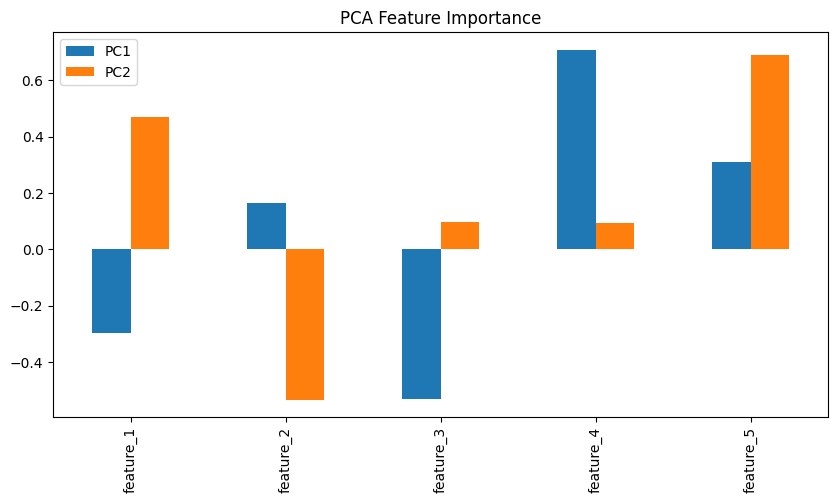

In [3]:
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# 샘플 데이터 생성
np.random.seed(42)
df = pd.DataFrame({
    "feature_1": np.random.rand(100),
    "feature_2": np.random.rand(100) * 10,
    "feature_3": np.random.rand(100) * 5,
    "feature_4": np.random.rand(100) * 2,
    "feature_5": np.random.rand(100) * 8
})

# 데이터 정규화 (PCA는 스케일 차이에 영향을 받음)
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df)

# PCA 적용
pca = PCA(n_components=2)  # 2개의 주성분 선택
pca.fit(df_scaled)

# 주성분별 컬럼 기여도 확인
importance = pd.DataFrame(pca.components_, columns=df.columns, index=[f'PC{i+1}' for i in range(pca.n_components_)])

# 컬럼별 중요도 출력
print("📌 PCA Component 별 컬럼 중요도")
print(importance.T)

# 컬럼별 중요도 시각화
importance.T.plot(kind='bar', figsize=(10, 5), title="PCA Feature Importance")

# 첫 번째 주성분(PC1)에서 중요한 3개 컬럼 선택
pc1_importance = np.abs(pca.components_[0])  # PC1의 절대값 중요도
important_features = np.array(df.columns)[np.argsort(pc1_importance)[-3:]]  # 상위 3개 선택

# 결과 출력
print("📌 중요한 3개 컬럼:", important_features)